# Analysis of the MBTI database

## Import librairies

Every libraries used in this notebook.

In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import networkx as nx
from difflib import get_close_matches
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import unicodedata
import re
from collections import defaultdict

c:\Users\dav-9\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## List of actor from previous DB

We will work with the 10 most important actors by movies.

In [2]:
# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

#print("Path to dataset files:", path)
#print("Fichiers dans le dossier :")
#print(os.listdir(path))

file_path_movie = os.path.join(path, "tmdb_5000_movies.csv")
file_path_credits = os.path.join(path, "tmdb_5000_credits.csv")

movies   = pd.read_csv(file_path_movie)
credits  = pd.read_csv(file_path_credits)

# Vérifier les colonnes
#print(credits.columns)
#print(movies.columns)

# Faire la jointure sur movie_id (credits) et id (movies)
data = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

In [3]:
def get_top_actors(cast_json, nbr) :
    try :
        cast_list = json.loads(cast_json)
        top = [actor['name'] for actor in cast_list]
        while len(top) < nbr :
            top.append(None)
        return top[:nbr]
    except :
        return [None] * nbr

def get_imdb_graph(data, nbr_actors=3, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()

    # Filtre par genre
    if genre is not None:
        df = df[df['genres'].str.contains(genre, na=False)]

    # S'assurer que release_date est bien en datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    # Extraire l'année
    df['release_year'] = df['release_date'].dt.year
    # Filtre par année et score
    df = df[(df['release_year'] >= firstyear) &
            (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) &
            (df['vote_average'] <= maxscore)]

    # Sélection des colonnes utiles
    df = df[['original_title', 'cast', 'release_year']]

    # Garder seulement les lignes où 'cast' contient au moins nbr_actors acteurs
    #df = df[df['cast'].apply(lambda x: len(json.loads(x)) >= nbr_actors)]

    # Une seule colonne 'actors' contenant une liste
    df['actors'] = df['cast'].apply(lambda x: get_top_actors(x, nbr_actors))

    # Création du graphe
    G = nx.Graph()

    for _, row in df.iterrows() :
        # Retirer les valeurs None de la liste
        actors = [a for a in row['actors'] if pd.notna(a)]

        # Ajouter toutes les combinaisons d'acteurs
        if len(actors) >= 2 :
            for i in range(len(actors)) :
                for j in range(i + 1, len(actors)) :
                    G.add_edge(actors[i], actors[j])

    return G

In [ ]:
G = get_imdb_graph(data, nbr_actors=10, firstyear=1990, lastyear=2009)

print(f"\tNumber of actors : {G.number_of_nodes():,}".replace(",", " "))
print(f"\tNumber of links  : {G.number_of_edges():,}".replace(",", " "))

	Number of actors : 11 637
	Number of links : 111 299


---
## Import datas MBTI

Import the datas from [Kaggle](https://www.kaggle.com/datasets/yuraslastya/celeb-mbti).

In [5]:
# Download latest version
path_mbti = kagglehub.dataset_download("yuraslastya/celeb-mbti")

print("Path to dataset files :", path_mbti)

# List all files
print("Fichiers dans le dossier :")
print(os.listdir(path_mbti))

Path to dataset files : C:\Users\dav-9\.cache\kagglehub\datasets\yuraslastya\celeb-mbti\versions\1
Fichiers dans le dossier :
['mbti_celebrities.csv']


## Datas in pandas

Save the datas in pandas to use them in the code.

In [ ]:
file_path_mbti = os.path.join(path_mbti, "mbti_celebrities.csv")

mbti = pd.read_csv(file_path_mbti)

print(f"Shape of the db : {mbti.shape}")

# See columns
print("Columns :")
print(mbti.columns.tolist())

# Check first rows
print()
print("Examples of datas")
print(mbti.head().to_string())

Sahpe of the db : (50878, 32)
Colonnes :
['id', 'name', 'cat_id', 'category', 'sub_cat_id', 'subcategory', 'four_letter', 'four_letter_total_voted', 'enneagram', 'enneagram_total_voted', 'socionics', 'socionics_total_voted', 'instinctual_variant', 'instinctual_variant_total_voted', 'tritype', 'tritype_total_voted', 'temperaments', 'temperaments_total_voted', 'attitudinal_psyche', 'attitudinal_psyche_total_voted', 'big_5_SLOAN', 'big_5_SLOAN_total_voted', 'classic_jungian', 'classic_jungian_total_voted', 'letter_1', 'letter_1_percentage', 'letter_2', 'letter_2_percentage', 'letter_3', 'letter_3_percentage', 'letter_4', 'letter_4_percentage']

Examples of datas
      id           name  cat_id category  sub_cat_id subcategory four_letter  four_letter_total_voted enneagram  enneagram_total_voted socionics  socionics_total_voted instinctual_variant  instinctual_variant_total_voted  tritype  tritype_total_voted           temperaments  temperaments_total_voted attitudinal_psyche  attitudinal_

## Clear db

We keep only important columns for our work and remove the duplicates.

In [7]:
# Columns to keep
cols = ['name', 'category', 'subcategory', 'four_letter', 'letter_1', 'letter_1_percentage',
    'letter_2', 'letter_2_percentage', 'letter_3', 'letter_3_percentage', 'letter_4', 'letter_4_percentage']

mbti = mbti[cols]

print(f"New shape : {mbti.shape}")
print()
print("Examples of datas")
print(mbti.head().to_string())

New shape : (50878, 12)

Examples of datas
            name category subcategory four_letter letter_1  letter_1_percentage letter_2  letter_2_percentage letter_3  letter_3_percentage letter_4  letter_4_percentage
0    Derek Jeter   Sports    Baseball        ISTJ        I                 0.70        S                 0.95        T                 0.84        J                 0.73
1  Ichiro Suzuki   Sports    Baseball        ISTP        I                 1.00        S                 0.97        T                 0.97        P                 0.74
2   Trevor Bauer   Sports    Baseball        ENTP        E                 0.62        N                 0.95        T                 0.95        P                 0.98
3   Zack Greinke   Sports    Baseball        INTP        I                 1.00        N                 0.97        T                 1.00        P                 0.81
4      Babe Ruth   Sports    Baseball        ESTP        E                 0.96        S                 0.

### Remove duplicates

In [8]:
print(f"Number of lines before cleaning : {len(mbti):,}".replace(",", " "))

mbti = mbti.drop_duplicates()

print(f"Number of lines after cleaning : {len(mbti):,}".replace(",", " "))

Number of lines before cleaning : 50 878
Number of lines after cleaning : 50 791


### Check similar names

After removing the duplicates, there is still some names that appears multiple times.

In [9]:
doublons = mbti[mbti.duplicated('name', keep=False)]
print(doublons['name'].value_counts())

name
Francesco Borromini    3
Reggie Jackson         2
James Paxton           2
Carlos Santana         2
Matt Chapman           2
                      ..
Perun                  2
Morana                 2
Mike Dean              2
Mani                   2
Philip II of France    2
Name: count, Length: 150, dtype: int64


In [10]:
print(doublons.sort_values(by='name').to_string())

                                  name     category                           subcategory four_letter letter_1  letter_1_percentage letter_2  letter_2_percentage letter_3  letter_3_percentage letter_4  letter_4_percentage
10124                                .   Noteworthy                             Criminals        ISTP        I                 1.00        S                 1.00        T                 1.00        P                 1.00
12294                                .     Business                              Business        INFP        I                 1.00        N                 1.00        F                 1.00        P                 1.00
50847                  Abraham Lincoln     Internet          Characters of Brandon Rogers        INTP        I                 1.00        N                 1.00        T                 1.00        P                 1.00
688                    Abraham Lincoln    Political                 Presidents of the USA        INTP        I  

### Code to do specific research

In [11]:
# List of actors to research
actors_to_find = ["Frankie Muniz", "Samuel L. Jackson"]

result = mbti[mbti['name'].isin(actors_to_find)]
print(result.to_string())

                   name     category                 subcategory four_letter letter_1  letter_1_percentage letter_2  letter_2_percentage letter_3  letter_3_percentage letter_4  letter_4_percentage
820   Samuel L. Jackson  Pop Culture  Actors and Actresses (USA)        ESTP        E                 0.98        S                 0.89        T                 0.96        P                 0.90
1358      Frankie Muniz  Pop Culture  Actors and Actresses (USA)        ENFP        E                 0.87        N                 0.83        F                 0.91        P                 0.91


---
## Distribution of personality in the db

Distribution 4 lettres :
	ENFP : 5 465 (10.8%)
	ENTP : 4 659 (9.2%)
	INFP : 3 776 (7.4%)
	ESFP : 3 619 (7.1%)
	INFJ : 3 578 (7.0%)
	ISFP : 3 392 (6.7%)
	INTP : 3 371 (6.6%)
	ENFJ : 3 247 (6.4%)
	ESTP : 2 847 (5.6%)
	INTJ : 2 732 (5.4%)
	ESFJ : 2 643 (5.2%)
	ISTP : 2 508 (4.9%)
	ENTJ : 2 402 (4.7%)
	ISTJ : 2 255 (4.4%)
	ISFJ : 2 243 (4.4%)
	ESTJ : 2 054 (4.0%)


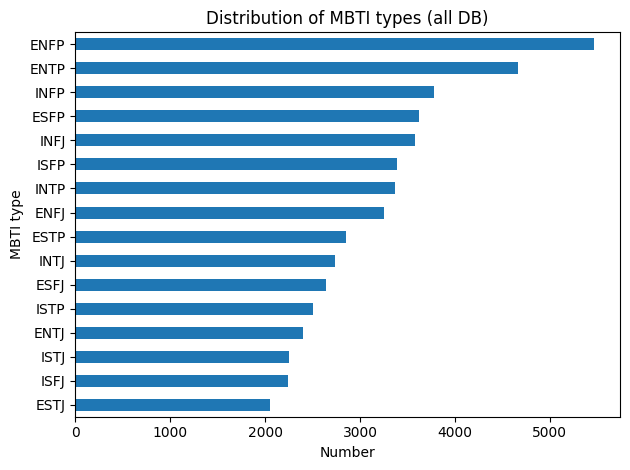

In [12]:
print("Distribution 4 lettres :")
for name, count in mbti['four_letter'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti) *100:.1f}%)".replace(",", " "))

# Comptage
counts = mbti['four_letter'].value_counts()

# Plot
plt.figure()
counts.sort_values().plot(kind='barh')

plt.title("Distribution of MBTI types (all DB)")
plt.xlabel("Number")
plt.ylabel("MBTI type")

plt.tight_layout()
plt.show()

## Distribution of letters in the db

- La première lettre est un I pour Introverti ou un E pour extraverti
- La deuxième lettre est un S pour Sensation ou un N pour intuition
- La troisième lettre est un T pour réflexif (Thinking) ou un F pour sentimental (feeling)
- La quatrième et dernière lettre est un J pour Jugement ou un P pour Perception

Distribution 1ere lettre (I/E) :
	E : 26 936 (53.0%)
	I : 23 855 (47.0%)

Distribution 2eme lettre (N/S) :
	N : 29 230 (57.5%)
	S : 21 561 (42.5%)

Distribution 2eme lettre (F/T) :
	F : 27 963 (55.1%)
	T : 22 828 (44.9%)

Distribution 4eme lettre (P/J) :
	P : 29 637 (58.4%)
	J : 21 154 (41.6%)


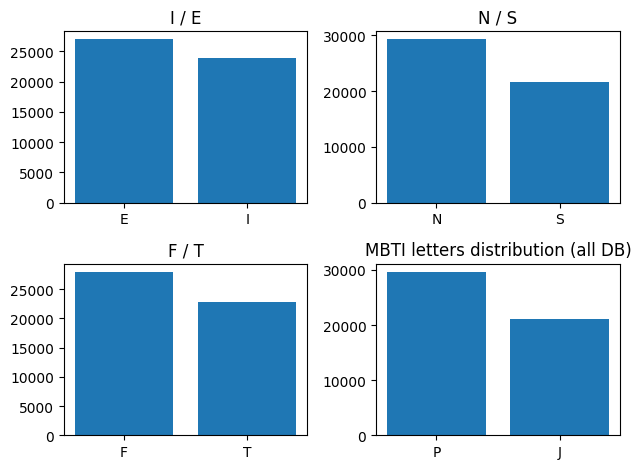

In [13]:
print("Distribution 1ere lettre (I/E) :")
for name, count in mbti['letter_1'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti) *100:.1f}%)".replace(",", " "))

print("\nDistribution 2eme lettre (N/S) :")
for name, count in mbti['letter_2'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti) *100:.1f}%)".replace(",", " "))

print("\nDistribution 2eme lettre (F/T) :")
for name, count in mbti['letter_3'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti) *100:.1f}%)".replace(",", " "))

print("\nDistribution 4eme lettre (P/J) :")
for name, count in mbti['letter_4'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti) *100:.1f}%)".replace(",", " "))

fig, axes = plt.subplots(2, 2)

# 1ère lettre (I/E)
counts1 = mbti['letter_1'].value_counts()
axes[0, 0].bar(counts1.index, counts1.values)
axes[0, 0].set_title("I / E")

# 2ème lettre (N/S)
counts2 = mbti['letter_2'].value_counts()
axes[0, 1].bar(counts2.index, counts2.values)
axes[0, 1].set_title("N / S")

# 3ème lettre (F/T)
counts3 = mbti['letter_3'].value_counts()
axes[1, 0].bar(counts3.index, counts3.values)
axes[1, 0].set_title("F / T")

# 4ème lettre (P/J)
counts4 = mbti['letter_4'].value_counts()
axes[1, 1].bar(counts4.index, counts4.values)
axes[1, 1].set_title("P / J")

plt.tight_layout()
plt.title("MBTI letters distribution (all DB)")
plt.show()    

## Independence analysis

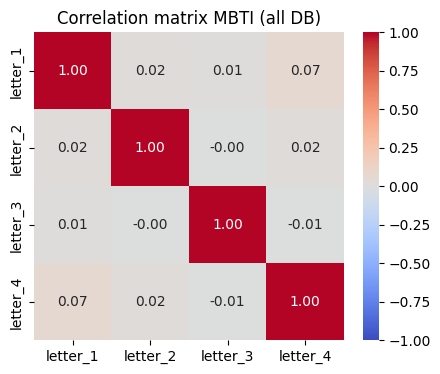

In [14]:
# Mapping to transform letters into numbers
mapping = {'letter_1': {'E': 1, 'I': 0},
            'letter_2': {'N': 1, 'S': 0},
            'letter_3': {'F': 1, 'T': 0},
            'letter_4': {'P': 1, 'J': 0}}

# Copy to calculate
mbti_numeric = mbti[['letter_1', 'letter_2', 'letter_3', 'letter_4']].copy()

# Apply mapping
for col, map_dict in mapping.items() :
    mbti_numeric[col] = mbti_numeric[col].map(map_dict)

# Correlation matrix
corr_matrix = mbti_numeric.corr()

# Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Correlation matrix MBTI (all DB)")
plt.show()

**Evaluation :**

*Valeur p :*

>H₀ (hypothèse nulle) : les variables sont indépendantes
>
>Avec beaucoup de données, même une relation faible → p-value ≈ 0
>
>p ≤ 0.05 → on rejette H₀ → les variables sont probablement dépendantes
>
>p > 0.05 → on ne rejette pas H₀ → pas de preuve de dépendance

*V de Cramér :*

>0 → aucune association
>
>1 → association parfaite

In [15]:
# Calculate cramer V formula
def cramers_v(contingency_table, chi2) :
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    # Simplified for 2x2
    return np.sqrt(phi2 / min(k - 1, r - 1))

dims = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

for i in range(len(dims)) :
    for j in range(i+1, len(dims)) :
        contingency_table = pd.crosstab(mbti[dims[i]], mbti[dims[j]])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        v = cramers_v(contingency_table, chi2)
        print(f"Test Chi2 {dims[i]}-{dims[j]} | p-value: {p:.4f} | V de Cramér: {v:.4f}")

Test Chi2 letter_1-letter_2 | p-value: 0.0000 | V de Cramér: 0.0216
Test Chi2 letter_1-letter_3 | p-value: 0.0101 | V de Cramér: 0.0114
Test Chi2 letter_1-letter_4 | p-value: 0.0000 | V de Cramér: 0.0698
Test Chi2 letter_2-letter_3 | p-value: 0.6378 | V de Cramér: 0.0021
Test Chi2 letter_2-letter_4 | p-value: 0.0001 | V de Cramér: 0.0173
Test Chi2 letter_3-letter_4 | p-value: 0.2457 | V de Cramér: 0.0052


---
## DB MBTI with actors only

We keep only the people which are registered as actors in the DB.

In [16]:
# Filter only actors
actors_mbti = mbti[mbti['subcategory'].str.contains('Actor', na=False)]

print(f"Number of actors in the MBTI database : {len(actors_mbti):,}".replace(",", " "))
print(actors_mbti['subcategory'].value_counts())

Number of actors in the MBTI database : 6 914
subcategory
Actors and Actresses (USA)             2426
Actors & Actresses (Asia)              1656
Actors & Actresses (Europe)             822
Actors and Actresses (UK & Ireland)     801
Actors & Actresses (Latin America)      502
Actors & Actresses (World)              341
Actors & Actresses (Canada)             223
Actors & Actresses (Oceania)            143
Name: count, dtype: int64


## Distribution of personality and letters of actors in the DB

- La première lettre est un I pour Introverti ou un E pour extraverti
- La deuxième lettre est un S pour Sensation ou un N pour intuition
- La troisième lettre est un T pour réflexif (Thinking) ou un F pour sentimental (feeling)
- La quatrième et dernière lettre est un J pour Jugement ou un P pour Perception

Distribution 4 lettres :
	ENFP : 1 016 (14.7%)
	ENFJ : 645 (9.3%)
	INFJ : 581 (8.4%)
	INFP : 565 (8.2%)
	ISFP : 551 (8.0%)
	ENTP : 537 (7.8%)
	ESFJ : 524 (7.6%)
	ESFP : 517 (7.5%)
	ISFJ : 366 (5.3%)
	ESTP : 355 (5.1%)
	ISTP : 306 (4.4%)
	INTP : 243 (3.5%)
	ENTJ : 195 (2.8%)
	INTJ : 180 (2.6%)
	ISTJ : 180 (2.6%)
	ESTJ : 153 (2.2%)


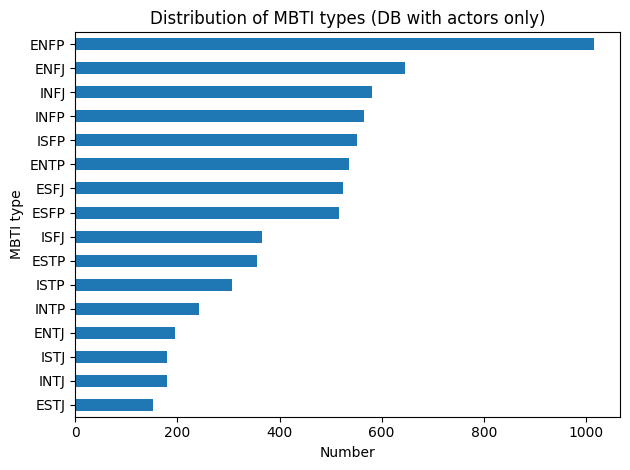


Distribution 1ere lettre (I/E) :
	E : 3 942 (57.0%)
	I : 2 972 (43.0%)

Distribution 2eme lettre (N/S) :
	N : 3 962 (57.3%)
	S : 2 952 (42.7%)

Distribution 2eme lettre (F/T) :
	F : 4 765 (68.9%)
	T : 2 149 (31.1%)

Distribution 4eme lettre (P/J) :
	P : 4 090 (59.2%)
	J : 2 824 (40.8%)


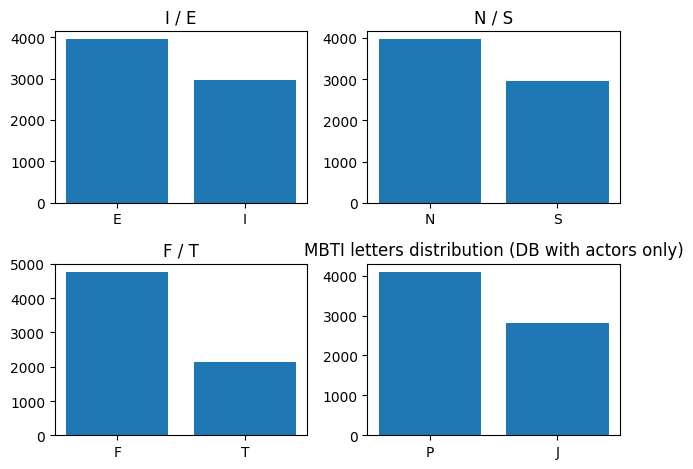

In [17]:
print("Distribution 4 lettres :")
for name, count in actors_mbti['four_letter'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(actors_mbti) *100:.1f}%)".replace(",", " "))
    
# Comptage
counts_a = actors_mbti['four_letter'].value_counts()

# Plot
plt.figure()
counts_a.sort_values().plot(kind='barh')

plt.title("Distribution of MBTI types (DB with actors only)")
plt.xlabel("Number")
plt.ylabel("MBTI type")

plt.tight_layout()
plt.show()

print("\nDistribution 1ere lettre (I/E) :")
for name, count in actors_mbti['letter_1'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(actors_mbti) *100:.1f}%)".replace(",", " "))

print("\nDistribution 2eme lettre (N/S) :")
for name, count in actors_mbti['letter_2'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(actors_mbti) *100:.1f}%)".replace(",", " "))

print("\nDistribution 2eme lettre (F/T) :")
for name, count in actors_mbti['letter_3'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(actors_mbti) *100:.1f}%)".replace(",", " "))

print("\nDistribution 4eme lettre (P/J) :")
for name, count in actors_mbti['letter_4'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(actors_mbti) *100:.1f}%)".replace(",", " "))

fig, axes = plt.subplots(2, 2)

# 1ère lettre (I/E)
counts1 = actors_mbti['letter_1'].value_counts()
axes[0, 0].bar(counts1.index, counts1.values)
axes[0, 0].set_title("I / E")

# 2ème lettre (N/S)
counts2 = actors_mbti['letter_2'].value_counts()
axes[0, 1].bar(counts2.index, counts2.values)
axes[0, 1].set_title("N / S")

# 3ème lettre (F/T)
counts3 = actors_mbti['letter_3'].value_counts()
axes[1, 0].bar(counts3.index, counts3.values)
axes[1, 0].set_title("F / T")

# 4ème lettre (P/J)
counts4 = actors_mbti['letter_4'].value_counts()
axes[1, 1].bar(counts4.index, counts4.values)
axes[1, 1].set_title("P / J")

plt.tight_layout()
plt.title("MBTI letters distribution (DB with actors only)")
plt.show()

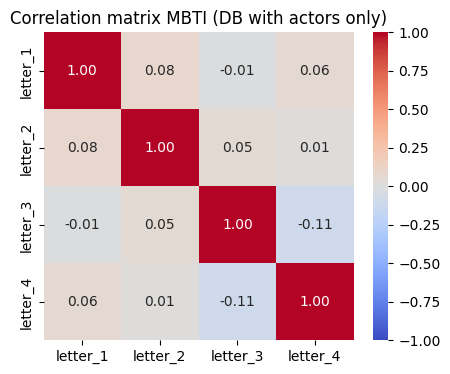

In [18]:
# Mapping to transform letters into numbers
mapping = {'letter_1': {'E': 1, 'I': 0},
            'letter_2': {'N': 1, 'S': 0},
            'letter_3': {'F': 1, 'T': 0},
            'letter_4': {'P': 1, 'J': 0}}

# Copy to calculate
actors_mbti_numeric = actors_mbti[['letter_1', 'letter_2', 'letter_3', 'letter_4']].copy()

# Apply mapping
for col, map_dict in mapping.items() :
    actors_mbti_numeric[col] = actors_mbti_numeric[col].map(map_dict)

# Correlation matrix
corr_matrix_actors = actors_mbti_numeric.corr()

# Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix_actors, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Correlation matrix MBTI (DB with actors only)")
plt.show()

**Evaluation :**

*Valeur p :*

>H₀ (hypothèse nulle) : les variables sont indépendantes
>
>Avec beaucoup de données, même une relation faible → p-value ≈ 0
>
>p ≤ 0.05 → on rejette H₀ → les variables sont probablement dépendantes
>
>p > 0.05 → on ne rejette pas H₀ → pas de preuve de dépendance

*V de Cramér :*

>0 → aucune association
>
>1 → association parfaite

In [19]:
# Calculate cramer V formula
def cramers_v(contingency_table, chi2) :
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    # Simplified for 2x2
    return np.sqrt(phi2 / min(k - 1, r - 1))

dims = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

for i in range(len(dims)) :
    for j in range(i+1, len(dims)) :
        contingency_table = pd.crosstab(actors_mbti[dims[i]], actors_mbti[dims[j]])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        v = cramers_v(contingency_table, chi2)
        print(f"Test Chi2 {dims[i]}-{dims[j]} | p-value: {p:.4f} | V de Cramér: {v:.4f}")

Test Chi2 letter_1-letter_2 | p-value: 0.0000 | V de Cramér: 0.0789
Test Chi2 letter_1-letter_3 | p-value: 0.4544 | V de Cramér: 0.0090
Test Chi2 letter_1-letter_4 | p-value: 0.0000 | V de Cramér: 0.0550
Test Chi2 letter_2-letter_3 | p-value: 0.0001 | V de Cramér: 0.0480
Test Chi2 letter_2-letter_4 | p-value: 0.4069 | V de Cramér: 0.0100
Test Chi2 letter_3-letter_4 | p-value: 0.0000 | V de Cramér: 0.1076


> V de Cramér a bit higher between letter 3 and 4, we check for more informations.

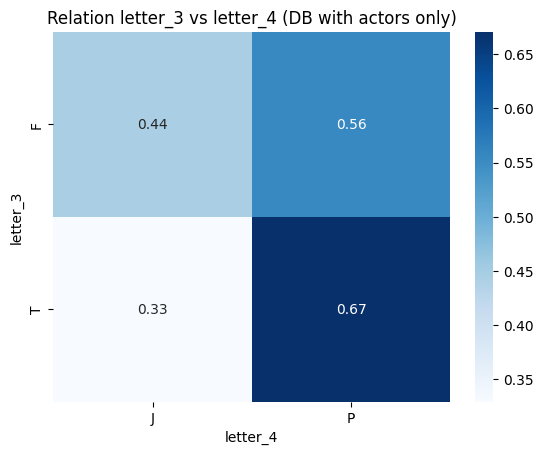

In [20]:
table = pd.crosstab(actors_mbti['letter_3'], actors_mbti['letter_4'], normalize='index')

sns.heatmap(table, annot=True, cmap='Blues')
plt.title("Relation letter_3 vs letter_4 (DB with actors only)")
plt.show()

---
## Join actor DB with MBTI DB

### Matching by name (identical)

In [21]:
# Actors from the graph
actors_in_graph = set(G.nodes())

# Actors in the MBTI database
actors_in_mbti = set(mbti['name'].tolist())

# Intersection: actors present in both
common_actors = actors_in_graph & actors_in_mbti

print(f"Number of actors in the graph : {len(actors_in_graph):,}".replace(",", " "))
print(f"Number of celebrities in MBTI : {len(actors_in_mbti):,}".replace(",", " "))
print(f"Number of shared actors       : {len(common_actors):,}".replace(",", " "))

Number of actors in the graph : 11 637
Number of celebrities in MBTI : 50 640
Number of shared actors       : 2 401


#### Verify for the DB with actors only

In [36]:
# Actors from the graph
actors_in_graph = set(G.nodes())

# Actors in the MBTI database (with actors only)
actors_in_mbti = set(actors_mbti['name'].tolist())

# Intersection: actors present in both
common_actors_2 = actors_in_graph & actors_in_mbti

print(f"Number of actors in the graph               : {len(actors_in_graph):,}".replace(",", " "))
print(f"Number of celebrities in MBTI (actors only) : {len(actors_in_mbti):,}".replace(",", " "))
print(f"Number of shared actors                     : {len(common_actors_2):,}".replace(",", " "))

Number of actors in the graph               : 11 637
Number of celebrities in MBTI (actors only) : 6 912
Number of shared actors                     : 1 912


In [23]:
# Difference between both results
difference = common_actors - common_actors_2

actors_to_find = []
print(f"Number of people in the graph match but not registered as actors : {len(difference)}\n")
for i in list(difference) :
    actors_to_find.append(i)

result = mbti[mbti['name'].isin(actors_to_find)]
print(f"{len(result['subcategory'].value_counts())} different subcategory catched :")
for name, count in result['subcategory'].value_counts().items():
    print(f"\t{name} : {count}")

Number of people in the graph match but not registered as actors : 489

62 different subcategory catched :
	Comedians : 94
	People of Classic Hollywood : 63
	Voice Acting : 55
	Film Directors : 49
	Hosts & Presenters : 25
	Models : 19
	Writers (Literature, Modern) : 13
	Basketball : 11
	Film & TV Crew : 9
	News & Journalists : 8
	Classic Pop & Contemporary : 8
	Football (American) : 8
	Government (USA) : 7
	Criminals : 6
	Artists (Animators) : 6
	Wrestling : 6
	European, Musicians : 6
	Martial Arts : 5
	Baseball : 5
	Business : 4
	Historical Figures (1900s) : 4
	Latin American, Musicians : 4
	MMA : 4
	Boxing : 4
	Presidents of the USA : 4
	Artists : 3
	Football (Soccer) : 3
	Famous For Being Famous : 3
	Political Commentators : 3
	Performers : 3
	Internet Personalities (Other) : 3
	General Vloggers : 3
	Skateboarding : 3
	Brazil, Musicians : 3
	Physics & Astronomy : 3
	Writers (Comics) : 2
	Wrestling (The Performers) : 2
	Activists : 2
	Skiing & Snowboarding : 2
	Tennis : 2
	Mathematic

## Match name even if not identical

We try different methods to match the names. Even if they are not identical, they can refer to the same person.

Testing with normalization but not really relevant results.

In [24]:
def normalize(name):
    # minuscules
    name = name.lower()
    
    # enlever accents
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
    
    # enlever ponctuation
    name = re.sub(r'[^a-z\s]', '', name)
    
    # trim espaces
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

# Actors from the graph
actors_in_graph = set(G.nodes())
# Actors in the MBTI database
actors_in_mbti = set(mbti['name'].tolist())
# Intersection: actors present in both
common_actors = actors_in_graph & actors_in_mbti

mbti_names = set(mbti['name'].tolist())
mbti_names = list(mbti_names - common_actors) # remove the perfect matches

# normalize names
mbti_names_norm = []
for name_norm in mbti_names :
    mbti_names_norm.append(normalize(name_norm))
actors_in_graph = actors_in_graph - common_actors # remove the perfect matches

mbti['name_norm'] = mbti['name'].apply(normalize)
actors_norm = {normalize(a): a for a in actors_in_graph}

matched = {}

# For each actor in the graph, find the closest name in MBTI
for actor in actors_norm :
    matches = get_close_matches(actor, mbti_names_norm, n=1, cutoff=0.9)
    if matches :
        matched[actor] = matches[0]

print(f"Number of matched actors : {len(matched)}")
print("\nMatches :")
for original, match in list(matched.items()) :
    if original != match :
        print(f"  {original:<20} match '{match}'")

Number of matched actors : 278

Matches :
  john morris          match 'john morrison'
  david cale           match 'david calle'
  jack wilson          match 'mack wilson'
  jamie campbell bower match 'jamie campbellbower'
  dragan micanovic     match 'dragana micalovic'
  daniel bernhardt     match 'daniel lenhardt'
  regan young          match 'megan young'
  juan fernandez       match 'juani fernandez'
  george anton         match 'georges danton'
  jessie thomas        match 'jesse thomas'
  ian roberts          match 'brian roberts'
  mark mason           match 'mark manson'
  ron lester           match 'jon lester'
  ben miller           match 'brent miller'
  michael caton        match 'michael anton'
  ed wheeler           match 'ted wheeler'
  joshua long          match 'joshua wong'
  mr lawrence          match 'mark lawrence'
  max martini          match 'max martin'
  jordan garrett       match 'jordan barrett'
  tina turner          match 'nina turner'
  david p smith    

In [25]:
# Actors from the graph
actors_in_graph = set(G.nodes())
# Actors in the MBTI database
actors_in_mbti = set(mbti['name'].tolist())
# Intersection: actors present in both
common_actors = actors_in_graph & actors_in_mbti


mbti_names = set(mbti['name'].tolist())
mbti_names = list(mbti_names - common_actors) # remove the perfect matches
actors_in_graph = actors_in_graph - common_actors # remove the perfect matches
matched = {}

# For each actor in the graph, find the closest name in MBTI
for actor in actors_in_graph :
    matches = get_close_matches(actor, mbti_names, n=1, cutoff=0.9)
    if matches :
        matched[actor] = matches[0]

print(f"Number of matched actors : {len(matched)}")
print("\nMatches :")
for original, match in list(matched.items()) :
    if original != match :
        print(f"  {original:<20} match '{match}'")

Number of matched actors : 223

Matches :
  John Morris          match 'John Morrison'
  David Cale           match 'David Calle'
  Jack Wilson          match 'Mack Wilson'
  Jamie Campbell Bower match 'Jamie Campbell-Bower'
  Dragan Mićanović     match 'Dragana Mićalović'
  Daniel Bernhardt     match 'Daniel Lenhardt'
  Regan Young          match 'Megan Young'
  Jessie Thomas        match 'Jesse Thomas'
  Mark Mason           match 'Mark Manson'
  John O'Hurley        match 'John O’Hurley'
  Ron Lester           match 'Jon Lester'
  Ben Miller           match 'Brent Miller'
  Betty White          match 'Betty White †'
  Joshua Long          match 'Joshua Wong'
  Max Martini          match 'Max Martin'
  Jordan Garrett       match 'Jordan Barrett'
  Tina Turner          match 'Nina Turner'
  Joie Lee             match 'Joe Lee'
  Andy Cohn            match 'Andy Cohen'
  Emma Kennedy         match 'Emma Kenney'
  Jake Weber           match 'Jake Webber'
  James Simon          match 'Ja

### Fuzzy-names

Swift code found on [Gitub](https://github.com/azamlerc/fuzzy-names). Rewritten in Python with LLM.

In [26]:
# Groupes de prénoms équivalents
NICKNAME_GROUPS = [
    {"alexander", "alexandra", "alex", "alejandro", "ali", "sasha", "alec", "xander"},
    {"catherine", "katherine", "kathryn", "kate", "katie", "kathy", "cathy", "cat", "kat",
     "ekaterina", "katia", "katja", "kay"},
    {"william", "will", "bill", "billy", "willie", "willy", "liam", "willem"},
    {"robert", "rob", "bob", "bobby", "robbie", "bert"},
    {"richard", "rick", "rich", "dick", "richie", "ricky"},
    {"james", "jim", "jimmy", "jamie"},
    {"john", "johnny", "jack", "jon"},
    {"michael", "mike", "mikey", "mikhail", "michel", "miguel"},
    {"elizabeth", "liz", "lizzie", "beth", "betty", "eliza", "ellie", "ella", "lisa", "libby"},
    {"margaret", "maggie", "meg", "marge", "peggy", "rita"},
    {"thomas", "tom", "tommy", "tomas"},
    {"charles", "charlie", "chuck", "carl", "carlos"},
    {"david", "dave", "davy"},
    {"joseph", "joe", "joey", "jose"},
    {"edward", "ed", "eddie", "ted", "teddy", "ned"},
    {"george", "georgie"},
    {"henry", "harry", "hank"},
    {"peter", "pete", "pedro"},
    {"anthony", "tony", "antonio"},
    {"matthew", "matt", "mateo"},
    {"nicholas", "nick", "nicolas", "nico", "nikola"},
    {"christopher", "chris", "topher"},
    {"stephen", "steven", "steve", "stefan", "etienne"},
    {"andrew", "andy", "drew"},
    {"patricia", "pat", "patty", "trish", "tricia"},
    {"jennifer", "jen", "jenny"},
    {"barbara", "barb", "babs"},
    {"dorothy", "dot", "dottie"},
    {"susan", "sue", "susie", "suzy"},
    {"nancy", "nan"},
    {"karen", "kari"},
    {"jessica", "jess", "jessie"},
    {"sarah", "sara"},
    {"emily", "emilie", "emma"},
    {"samantha", "sam", "sammie"},
    {"theodore", "theo", "ted", "teddy"},
    {"ronald", "ron", "ronny", "ronnie"},
    {"donald", "don", "donny"},
    {"daniel", "dan", "danny"},
    {"benjamin", "ben", "benny", "benji"},
    {"lawrence", "larry", "lars"},
    {"kenneth", "ken", "kenny"},
    {"jonathan", "jon", "jonny"},
    {"timothy", "tim", "timmy"},
    {"gregory", "greg"},
    {"raymond", "ray"},
    {"frank", "francis", "francisco"},
    {"eugene", "gene"},
    {"harold", "hal", "harry"},
    {"walter", "walt"},
    {"arthur", "art"},
    {"fred", "frederick", "freddy", "fritz"},
    {"maria", "mary", "marie", "masha", "mae", "molly", "polly"},
    {"anna", "anne", "ann", "annie", "ana"},
    {"helen", "elena", "eleanor", "elaine", "nell"},
    {"virginia", "ginny"},
    {"beatrice", "bea", "trixie"},
    {"constance", "connie"},
    {"lorraine", "lorrie"},
    {"bart", "bartholomew", "bartlomiej"},
]

# Index nickname : prénom → groupe de variantes
def build_nickname_index(groups):
    index = {}
    for group in groups:
        for name in group:
            index[name] = group
    return index

NICKNAME_INDEX = build_nickname_index(NICKNAME_GROUPS)


# simplification
PUNCTUATION_TO_REMOVE = set(".,()|\"/")
SUFFIXES = {"esq", "jd", "mba", "pa", "phd", "jr", "ii", "iii", "iv", "sr", "md"}

def simplify(name: str) -> str:
    """Normalise un prénom ou nom de famille."""
    # minuscules
    s = name.lower()
    # suppression des diacritiques
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    # ł → l (non couvert par la décomposition NFD)
    s = s.replace("ł", "l")
    # suppression ponctuation
    s = "".join(c for c in s if c not in PUNCTUATION_TO_REMOVE)
    # tirets → espaces
    s = s.replace("-", " ")
    # suppression du contenu entre parenthèses (ex: "Alice (미선)")
    s = re.sub(r'\(.*?\)', '', s)
    # suppression des suffixes
    tokens = s.split()
    tokens = [t for t in tokens if t not in SUFFIXES]
    s = " ".join(tokens).strip()
    return s


class Person:
    def __init__(self, first: str, last: str, original_name: str = None):
        self.first = first
        self.last = last
        self.original_name = original_name or f"{first} {last}"

        self.simple_first = simplify(first)
        self.simple_last  = simplify(last)
        # full = concatenation sans espaces de simple_first + simple_last
        self.simple_full  = (self.simple_first + self.simple_last).replace(" ", "")

    def __repr__(self):
        return f"Person('{self.first}', '{self.last}')"


# match
def name_variations(name: str) -> list:
    """
    Retourne toutes les variantes utiles d'un nom composé.
    Ex: "cheuk kwan" → ["chukkwan", "cheuk", "kwan"]
    Les initiales (longueur 1) sont ignorées.
    """
    if " " not in name:
        return [name]
    parts = [p for p in name.split() if len(p) > 1]
    return [name.replace(" ", "")] + parts


class FuzzyNameMatcher:
    def __init__(self, people: list):
        self.people = people
        self._first_index: dict = defaultdict(list)
        self._last_index:  dict = defaultdict(list)
        self._full_index:  dict = defaultdict(list)
        self._build_indexes()

    def _build_indexes(self):
        for p in self.people:
            self._first_index[p.simple_first].append(p)
            self._last_index[p.simple_last].append(p)
            self._full_index[p.simple_full].append(p)

            # combinaisons prénom × nom pour les noms composés
            if " " in p.simple_first or " " in p.simple_last:
                for f in name_variations(p.simple_first):
                    for l in name_variations(p.simple_last):
                        self._full_index[f + l].append(p)

    def match(self, person: Person) -> Person | None:
        # 1. Match exact sur le full name simplifié
        if hits := self._full_index.get(person.simple_full):
            return hits[0]

        # 2. Variantes de noms composés
        if " " in person.simple_first or " " in person.simple_last:
            for f in name_variations(person.simple_first):
                for l in name_variations(person.simple_last):
                    if hits := self._full_index.get(f + l):
                        return hits[0]

        # 3. Nicknames
        return self._match_by_nickname(person)

    def _match_by_nickname(self, person: Person) -> Person | None:
        last_hits = self._last_index.get(person.simple_last, [])
        if not last_hits:
            return None

        nickname_group = NICKNAME_INDEX.get(person.simple_first)
        if not nickname_group:
            return None

        for variant in nickname_group:
            first_hits = self._first_index.get(variant, [])
            intersection = [p for p in first_hits if p in last_hits]
            if intersection:
                return intersection[0]

        return None

def parse_full_name(full_name: str) -> Person:
    """
    Convertit un nom complet (string) en Person(first, last).
    Convention : dernier token = nom de famille, reste = prénom.
    """
    tokens = full_name.strip().split()
    if len(tokens) == 1:
        return Person(tokens[0], "", full_name)
    return Person(" ".join(tokens[:-1]), tokens[-1], full_name)


def match_actor_databases(actors_in_graph: set, mbti_names_set: set) -> dict:
    """
    Retourne un dict {graph_name: mbti_name} pour tous les matches trouvés.
    Gère d'abord les perfect matches, puis le fuzzy matching.
    """
    # Perfect matches
    common = actors_in_graph & mbti_names_set
    result = {name: name for name in common}
    print(f"Perfect matches       : {len(common):,}")

    # Noms restants
    remaining_graph = actors_in_graph - common
    remaining_mbti  = list(mbti_names_set - common)

    # Construction du matcher sur les noms MBTI restants
    mbti_people = [parse_full_name(n) for n in remaining_mbti]
    matcher = FuzzyNameMatcher(mbti_people)

    fuzzy_matched = {}
    for actor_name in remaining_graph:
        query = parse_full_name(actor_name)
        hit = matcher.match(query)
        if hit:
            fuzzy_matched[actor_name] = hit.original_name

    print(f"Fuzzy matches         : {len(fuzzy_matched):,}")
    print(f"Non matchés           : {len(remaining_graph) - len(fuzzy_matched):,}")
    print("\nDétail des fuzzy matches :")
    for src, tgt in fuzzy_matched.items():
        if src != tgt:
            print(f"  {src:<35} → '{tgt}'")

    result.update(fuzzy_matched)
    return result


# utilisation
actors_in_graph = set(G.nodes())
actors_in_mbti  = set(mbti['name'].tolist())

common_actors = actors_in_graph & actors_in_mbti
actors_in_mbti = actors_in_mbti - common_actors
actors_in_graph = actors_in_graph - common_actors # on enleve les perfect match 

all_matches = match_actor_databases(actors_in_graph, actors_in_mbti)

print(f"Acteurs matchés (approx)  : {len(all_matches):,}")
print("\nNoms match :")
for original, match in list(all_matches.items()) :
    if original != match :
        print(f"  {original:<30} match '{match}'")

Perfect matches       : 0
Fuzzy matches         : 235
Non matchés           : 9,001

Détail des fuzzy matches :
  John Morris                         → 'Jack Morris'
  Drena De Niro                       → 'Robert de Niro'
  Jack Wilson                         → 'John Wilson'
  Jamie Campbell Bower                → 'Jamie Campbell-Bower'
  Michael Guarino Jr.                 → 'Michael Lam, MD'
  George Martin                       → 'George R. R. Martin'
  Cristián de la Fuente               → 'Félix Rodríguez de la Fuente'
  Nelson Edwin Rodríguez              → 'Ed Bassmaster (Edwin Rodriguez)'
  Rose Keegan                         → 'Olivia Rose Keegan'
  James 'Kamal' Gray                  → 'James Gray'
  Carlos Andrés Gómez                 → 'Carlos Gomez'
  Shenae Grimes                       → 'Shenae Grimes-Beech'
  Eric Michael Cole                   → 'Michael Cole'
  Jahnni St. John                     → 'Jon St. John'
  Bob Greene                          → 'Robert Greene

> Better results than previous method and much faster. Unfortunately, not perfect and then need a manual checking or simple sorting.

## Sorting the supposed matching

With the list of supposed matches, we need to sort them because some of them are correct match and others not. We will apply bigger restrictions on this reduced list to add some people to my match list.

In [27]:
# if True assume that name1 and name2 is the same person
def same_person(name1, name2) :
    def normalize(name) :
        # replace ., ', ’ and , with space
        name = name.replace('.', ' ').replace(',', ' ').replace('’', ' ').replace("'", ' ')
        
        # remove the accents
        name = unicodedata.normalize('NFKD', name)
        name = name.encode('ascii', 'ignore').decode('utf-8')
        
        # lowercase
        name = name.lower()
        
        # remove multiple spaces
        name = re.sub(r'\s+', ' ', name)
        
        name = name.strip()
        
        return name
    
    return normalize(name1) == normalize(name2)

valid_match = {}
invalid_match = {}
for original, match in list(matched.items()) :
    if same_person(original, match) :
        valid_match[original] = match
    else :
        invalid_match[original] = match

In [28]:
print(f"Acteurs valides : {len(valid_match)}")
print("\nNoms match :")
for original, match in list(valid_match.items()) :
    print(f"  {original:<20} match '{match}'")

Acteurs valides : 45

Noms match :
  John O'Hurley        match 'John O’Hurley'
  Betty White          match 'Betty White †'
  Michael Peña         match 'Michael Pena'
  Óscar Casas          match 'Oscar Casas'
  Luis Guzmán          match 'Luis Guzman'
  Ken Griffey, Jr.     match 'Ken Griffey Jr.'
  Jordi Mollà          match 'Jordi Mollá'
  John Gallagher Jr.   match 'John Gallagher, Jr.'
  E.G. Daily           match 'E. G. Daily'
  Traci Lords          match 'Traci  Lords'
  Zoe Saldana          match 'Zoe Saldaña'
  George Perez         match 'George Pérez'
  J.K. Simmons         match 'J. K. Simmons'
  Robert De Niro       match 'Robert de Niro'
  J.B. Smoove          match 'J. B. Smoove'
  Gina McKee           match 'Gina Mckee'
  Ryunosuke Kamiki     match 'Ryūnosuke Kamiki'
  Elyas M’Barek        match 'Elyas M'Barek'
  Murilo Benicio       match 'Murilo Benício'
  Benicio del Toro     match 'Benicio Del Toro'
  Carlos Gómez         match 'Carlos Gomez'
  Oscar Nunez         

In [29]:
print(f"Acteurs invalides : {len(invalid_match):,}")
print("\nNoms match :")
for original, match in list(invalid_match.items()) :
    print(f"  {original:<20} match '{match}'")

Acteurs invalides : 178

Noms match :
  John Morris          match 'John Morrison'
  David Cale           match 'David Calle'
  Jack Wilson          match 'Mack Wilson'
  Jamie Campbell Bower match 'Jamie Campbell-Bower'
  Dragan Mićanović     match 'Dragana Mićalović'
  Daniel Bernhardt     match 'Daniel Lenhardt'
  Regan Young          match 'Megan Young'
  Jessie Thomas        match 'Jesse Thomas'
  Mark Mason           match 'Mark Manson'
  Ron Lester           match 'Jon Lester'
  Ben Miller           match 'Brent Miller'
  Joshua Long          match 'Joshua Wong'
  Max Martini          match 'Max Martin'
  Jordan Garrett       match 'Jordan Barrett'
  Tina Turner          match 'Nina Turner'
  Joie Lee             match 'Joe Lee'
  Andy Cohn            match 'Andy Cohen'
  Emma Kennedy         match 'Emma Kenney'
  Jake Weber           match 'Jake Webber'
  James Simon          match 'James Simpson'
  Nadim Sawalha        match 'Nadia Sawalha'
  Andrew Pang          match 'Andrew

In [37]:
# if True assume that name1 and name2 is the same person
def same_person(name1, name2) :
    def normalize(name) :
        # replace ., ', ’ and , with space
        name = name.replace('.', ' ').replace(',', ' ').replace('’', ' ').replace("'", ' ')
        
        # remove the accents
        name = unicodedata.normalize('NFKD', name)
        name = name.encode('ascii', 'ignore').decode('utf-8')
        
        # lowercase
        name = name.lower()
        
        # remove multiple spaces
        name = re.sub(r'\s+', ' ', name)
        
        name = name.strip()
        
        return name
    
    return normalize(name1) == normalize(name2)

valid_match_all = {}
invalid_match_all = {}
for original, match in list(all_matches.items()) :
    if same_person(original, match) :
        valid_match_all[original] = match
    else :
        invalid_match_all[original] = match

In [38]:
print(f"Acteurs valides : {len(valid_match_all)}")
print("\nNoms match :")
for original, match in list(valid_match_all.items()) :
    print(f"  {original:<20} match '{match}'")

Acteurs valides : 42

Noms match :
  Michael Peña         match 'Michael Pena'
  Óscar Casas          match 'Oscar Casas'
  Luis Guzmán          match 'Luis Guzman'
  Ken Griffey, Jr.     match 'Ken Griffey Jr.'
  Jordi Mollà          match 'Jordi Mollá'
  John Gallagher Jr.   match 'John Gallagher, Jr.'
  E.G. Daily           match 'E. G. Daily'
  Traci Lords          match 'Traci  Lords'
  Zoe Saldana          match 'Zoe Saldaña'
  George Perez         match 'George Pérez'
  J.K. Simmons         match 'J. K. Simmons'
  Robert De Niro       match 'Robert de Niro'
  J.B. Smoove          match 'J. B. Smoove'
  Gina McKee           match 'Gina Mckee'
  Ryunosuke Kamiki     match 'Ryūnosuke Kamiki'
  Murilo Benicio       match 'Murilo Benício'
  Benicio del Toro     match 'Benicio Del Toro'
  Carlos Gómez         match 'Carlos Gomez'
  Oscar Nunez          match 'Oscar Nuñez'
  Gael García Bernal   match 'Gael Garcia Bernal'
  Alex D. Linz         match 'Alex D Linz'
  Sônia Braga        

In [41]:
print(f"Acteurs invalides : {len(invalid_match_all):,}")
print("\nNoms match :")
for original, match in list(invalid_match_all.items()) :
    print(f"  {original:<25} match '{match}'")

Acteurs invalides : 193

Noms match :
  John Morris               match 'Jack Morris'
  Drena De Niro             match 'Robert de Niro'
  Jack Wilson               match 'John Wilson'
  Jamie Campbell Bower      match 'Jamie Campbell-Bower'
  Michael Guarino Jr.       match 'Michael Lam, MD'
  George Martin             match 'George R. R. Martin'
  Cristián de la Fuente     match 'Félix Rodríguez de la Fuente'
  Nelson Edwin Rodríguez    match 'Ed Bassmaster (Edwin Rodriguez)'
  Rose Keegan               match 'Olivia Rose Keegan'
  James 'Kamal' Gray        match 'James Gray'
  Carlos Andrés Gómez       match 'Carlos Gomez'
  Shenae Grimes             match 'Shenae Grimes-Beech'
  Eric Michael Cole         match 'Michael Cole'
  Jahnni St. John           match 'Jon St. John'
  Bob Greene                match 'Robert Greene'
  James Fox                 match 'Charles James Fox'
  Ed Wheeler                match 'Ted Wheeler'
  Shedrack Anderson III     match 'Will Anderson Jr.'
  Gong

---
## Actors matched with MBTI

In [30]:
# Actors from the graph
actors_in_graph = set(G.nodes())

# convert to reverse dictionary
valid_inverse = {v: k for k, v in valid_match.items()}
# Actors in the MBTI database
mbti['name_cleaned'] = mbti['name'].replace(valid_inverse)
actors_in_mbti = set(mbti['name_cleaned'].tolist())

# Intersection: actors present in both
common_actors = actors_in_graph & actors_in_mbti

print(f"Number of actors in the graph : {len(actors_in_graph):,}".replace(",", " "))
print(f"Number of celebrities in MBTI : {len(actors_in_mbti):,}".replace(",", " "))
print(f"Number of shared actors       : {len(common_actors):,}".replace(",", " "))

Number of actors in the graph : 11 637
Number of celebrities in MBTI : 50 640
Number of shared actors       : 2 446


## Distribution of actors matched with MBTI

Distribution 4 lettres :
	ENFP : 321 (13.3%)
	ENTP : 226 (9.4%)
	ENFJ : 201 (8.3%)
	ESFJ : 187 (7.7%)
	INFJ : 179 (7.4%)
	INFP : 175 (7.2%)
	ISFP : 147 (6.1%)
	ESTP : 146 (6.0%)
	ESFP : 134 (5.5%)
	ISTP : 131 (5.4%)
	INTP : 127 (5.3%)
	ISFJ : 108 (4.5%)
	ENTJ : 96 (4.0%)
	ISTJ : 94 (3.9%)
	INTJ : 81 (3.4%)
	ESTJ : 63 (2.6%)


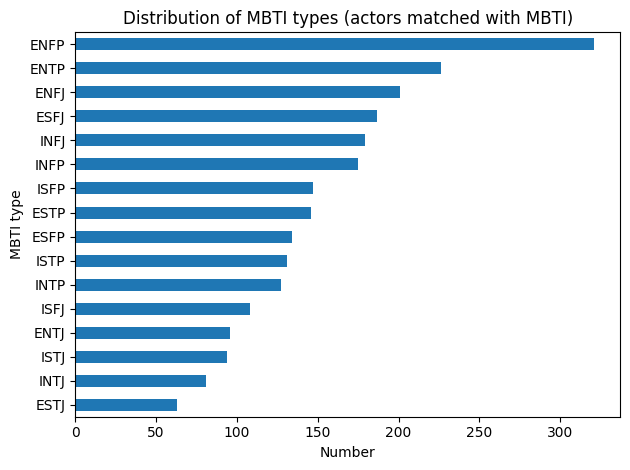


Distribution 1ere lettre (I/E) :
	E : 1 374 (56.9%)
	I : 1 042 (43.1%)

Distribution 2eme lettre (N/S) :
	N : 1 406 (58.2%)
	S : 1 010 (41.8%)

Distribution 2eme lettre (F/T) :
	F : 1 452 (60.1%)
	T : 964 (39.9%)

Distribution 4eme lettre (P/J) :
	P : 1 407 (58.2%)
	J : 1 009 (41.8%)


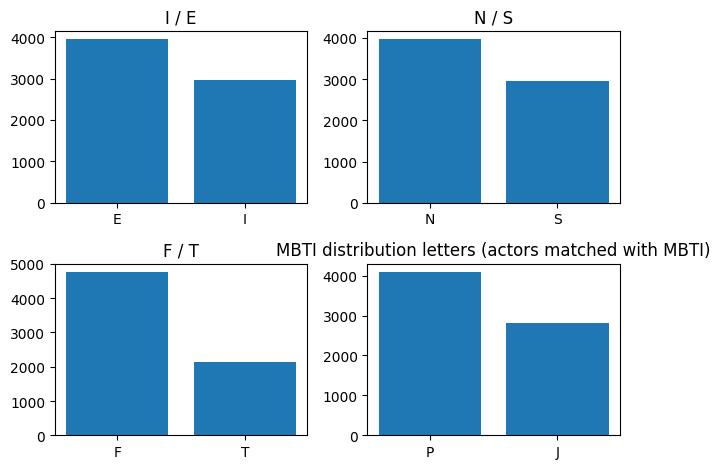

In [31]:
mbti_match = mbti[mbti['name'].isin(common_actors)]

print("Distribution 4 lettres :")
for name, count in mbti_match['four_letter'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti_match) *100:.1f}%)".replace(",", " "))

# Comptage
counts_m = mbti_match['four_letter'].value_counts()

# Plot
plt.figure()
counts_m.sort_values().plot(kind='barh')

plt.title("Distribution of MBTI types (actors matched with MBTI)")
plt.xlabel("Number")
plt.ylabel("MBTI type")

plt.tight_layout()
plt.show()

print("\nDistribution 1ere lettre (I/E) :")
for name, count in mbti_match['letter_1'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti_match) *100:.1f}%)".replace(",", " "))

print("\nDistribution 2eme lettre (N/S) :")
for name, count in mbti_match['letter_2'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti_match) *100:.1f}%)".replace(",", " "))

print("\nDistribution 2eme lettre (F/T) :")
for name, count in mbti_match['letter_3'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti_match) *100:.1f}%)".replace(",", " "))

print("\nDistribution 4eme lettre (P/J) :")
for name, count in mbti_match['letter_4'].value_counts().items() :
    print(f"\t{name} : {count:,} ({count/len(mbti_match) *100:.1f}%)".replace(",", " "))

fig, axes = plt.subplots(2, 2)

# 1ère lettre (I/E)
counts1 = actors_mbti['letter_1'].value_counts()
axes[0, 0].bar(counts1.index, counts1.values)
axes[0, 0].set_title("I / E")

# 2ème lettre (N/S)
counts2 = actors_mbti['letter_2'].value_counts()
axes[0, 1].bar(counts2.index, counts2.values)
axes[0, 1].set_title("N / S")

# 3ème lettre (F/T)
counts3 = actors_mbti['letter_3'].value_counts()
axes[1, 0].bar(counts3.index, counts3.values)
axes[1, 0].set_title("F / T")

# 4ème lettre (P/J)
counts4 = actors_mbti['letter_4'].value_counts()
axes[1, 1].bar(counts4.index, counts4.values)
axes[1, 1].set_title("P / J")

plt.tight_layout()
plt.title("MBTI distribution letters (actors matched with MBTI)")
plt.show()

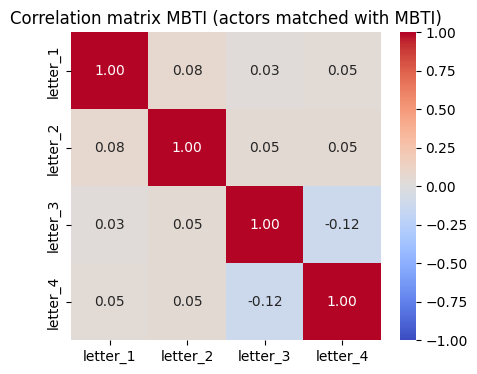

In [32]:
# Mapping to transform letters into numbers
mapping = {'letter_1': {'E': 1, 'I': 0},
            'letter_2': {'N': 1, 'S': 0},
            'letter_3': {'F': 1, 'T': 0},
            'letter_4': {'P': 1, 'J': 0}}

# Copy to calculate
actors_mbti_match = mbti_match[['letter_1', 'letter_2', 'letter_3', 'letter_4']].copy()

# Appliquer le mapping
for col, map_dict in mapping.items() :
    actors_mbti_match[col] = actors_mbti_match[col].map(map_dict)

# Apply mapping
corr_matrix_match = actors_mbti_match.corr()

# Correlation matrix
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix_match, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Correlation matrix MBTI (actors matched with MBTI)")
plt.show()

In [33]:
# Calculate cramer V formula
def cramers_v(contingency_table, chi2) :
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    # Simplified for 2x2
    return np.sqrt(phi2 / min(k - 1, r - 1))

dims = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

for i in range(len(dims)) :
    for j in range(i+1, len(dims)) :
        contingency_table = pd.crosstab(mbti_match[dims[i]], mbti_match[dims[j]])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        v = cramers_v(contingency_table, chi2)
        print(f"Test Chi2 {dims[i]}-{dims[j]} | p-value: {p:.4f} | V de Cramér: {v:.4f}")

        #print(f"Test Chi2 entre Lettre {i+1} et {j+1} - p-value : {p:.4f}")

Test Chi2 letter_1-letter_2 | p-value: 0.0003 | V de Cramér: 0.0744
Test Chi2 letter_1-letter_3 | p-value: 0.1604 | V de Cramér: 0.0286
Test Chi2 letter_1-letter_4 | p-value: 0.0283 | V de Cramér: 0.0446
Test Chi2 letter_2-letter_3 | p-value: 0.0102 | V de Cramér: 0.0523
Test Chi2 letter_2-letter_4 | p-value: 0.0130 | V de Cramér: 0.0505
Test Chi2 letter_3-letter_4 | p-value: 0.0000 | V de Cramér: 0.1167


> V de Cramér a bit higher between letter 3 and 4, we check for more informations.

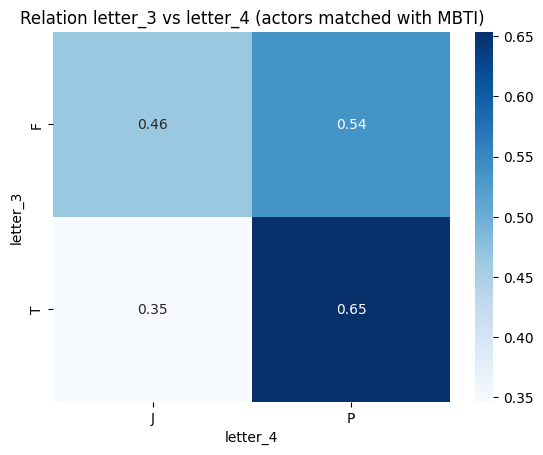

In [34]:
table = pd.crosstab(mbti_match['letter_3'], mbti_match['letter_4'], normalize='index')

sns.heatmap(table, annot=True, cmap='Blues')
plt.title("Relation letter_3 vs letter_4 (actors matched with MBTI)")
plt.show()

### Graph 

In [ ]:
# On garde les colonnes voulues + l'index
cols_to_keep = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

# 'index' crée un dictionnaire de type {nom: {col1: val1, col2: val2...}}
mbti_unique = mbti.drop_duplicates(subset=['name_cleaned'], keep='first')

# 2. Maintenant on peut créer le dictionnaire sans erreur
mbti_dict = mbti_unique.set_index('name_cleaned')[cols_to_keep].to_dict(orient='index')

for actor in G.nodes() :
    # mbti_data sera soit le dict des 4 lettres, soit None
    mbti_data = mbti_dict.get(actor) 
    
    if mbti_data :
        # On injecte directement les 4 clés/valeurs dans le noeud
        G.nodes[actor].update(mbti_data)
        
        #full_type = "".join([mbti_data[f'letter_{i}'] for i in range(1, 5)])
        #G.nodes[actor]['mbti_full'] = full_type

# Vérifier
actors_with_mbti = [(n, d['letter_1']) for n, d in G.nodes(data=True) if 'letter_1' in d]
print(f"\nActeurs du graphe avec MBTI : {len(actors_with_mbti)}")
print("\nExemples :")
for name, mbti_type in actors_with_mbti[:10] :
    print(f"  {name:<20} : {mbti_type}")


Acteurs du graphe avec MBTI : 2446

Exemples :
  Sam Worthington                : I
  Zoe Saldana                    : I
  Sigourney Weaver               : I
  Stephen Lang                   : I
  Michelle Rodriguez             : E
  Giovanni Ribisi                : I
  Laz Alonso                     : E
  Johnny Depp                    : I
  Orlando Bloom                  : I
  Keira Knightley                : E
